# Results: finding nine landmarks on cat faces

This notebook is where I keep the results of my landmark experiments. The question I am trying to answer:
**does masked-autoencoder pretraining on unlabeled cat photos help a Vision Transformer find landmarks?**

To answer it I need two runs that differ in only one thing, the starting weights:

| Run | Starting weights | Status |
|---|---|---|
| `pose_scratch` | random | done |
| `pose_mae` | the encoder from MAE pretraining | done |

Both runs are finished. Every cell below loops over the runs in `results/`, so the two sit side by side on the same
plots. The short answer is at the end: **yes, pretraining helps, by 14% on the test set**.

## How I measure error

Every face has nine landmarks: two eyes, the mouth, and three points on each ear. For each landmark I take the
distance between my prediction and the hand-placed point, and divide it by the distance between the two eyes.
This **normalised mean error (NME)** makes faces of different sizes comparable.

A quick example to make the number concrete: if the eyes are 100 pixels apart and my mouth prediction is off by
6 pixels, that landmark's error is 6 / 100 = 0.06. A face's NME is the average over its nine landmarks.

I also report a **failure rate**: the share of faces whose NME is above 0.1, i.e. faces where the points are,
on average, off by more than a tenth of the eye distance.

All numbers here are on the **validation split** (1,000 faces). I am keeping the test split untouched until both
runs are finished, and I will evaluate it once at the end.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
LABELS = {"pose_scratch": "from scratch", "pose_mae": "from MAE"}

runs = {}
for folder in [RESULTS / name for name in LABELS if (RESULTS / name).exists()]:
    runs[folder.name] = {
        "config": json.loads((folder / "config.json").read_text()),
        "metrics": [json.loads(line) for line in (folder / "metrics.jsonl").read_text().splitlines()],
        "val": json.loads((folder / "eval_val.json").read_text()),
        "test": json.loads((folder / "eval_test.json").read_text()),
    }
print("runs found:", list(runs))

runs found: ['pose_scratch', 'pose_mae']


## Step 1: pretraining with a masked autoencoder

Before any landmarks, I pretrained the encoder as a masked autoencoder on unlabeled cats: 13,061 faces (the CAT
training images plus AFHQ's cat training set), 300 epochs, about 8 hours on my laptop's GPU. Each image is cut
into 196 patches, three quarters of them are hidden, and the model has to fill them back in. The held-out curve
uses CAT validation and AFHQ test faces with fixed masks, so it is comparable from epoch to epoch.

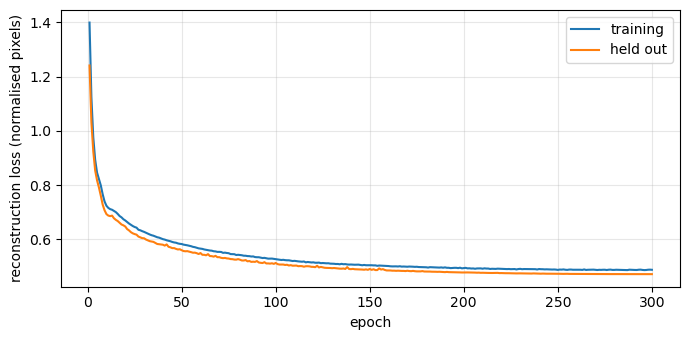

held-out loss: epoch 1 1.2407, epoch 100 0.5134, epoch 300 0.4723


In [2]:
mae = [json.loads(line) for line in (RESULTS / "mae" / "metrics.jsonl").read_text().splitlines()]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot([r["epoch"] for r in mae], [r["loss"] for r in mae], label="training")
ax.plot([r["epoch"] for r in mae], [r["held_out"] for r in mae], label="held out")
ax.set_xlabel("epoch")
ax.set_ylabel("reconstruction loss (normalised pixels)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"held-out loss: epoch 1 {mae[0]['held_out']:.4f}, epoch 100 {mae[99]['held_out']:.4f}, "
      f"epoch 300 {mae[-1]['held_out']:.4f}")

The held-out loss sits *below* the training loss the whole way, which surprised me at first. My guess (not
tested) is that it comes from the inputs rather than from the model: training sees random crops, some of them
zoomed in on a quarter of the image, while the held-out faces are always shown whole, and a whole face gives more
context to fill the gaps from. Either way, the two curves flatten together, so there is no sign of overfitting.

Here is what the model makes of faces it never trained on. Columns, left to right: the input, what the
encoder actually gets to see (grey = hidden), the decoder's prediction for every patch, and the prediction pasted
into the hidden patches only.

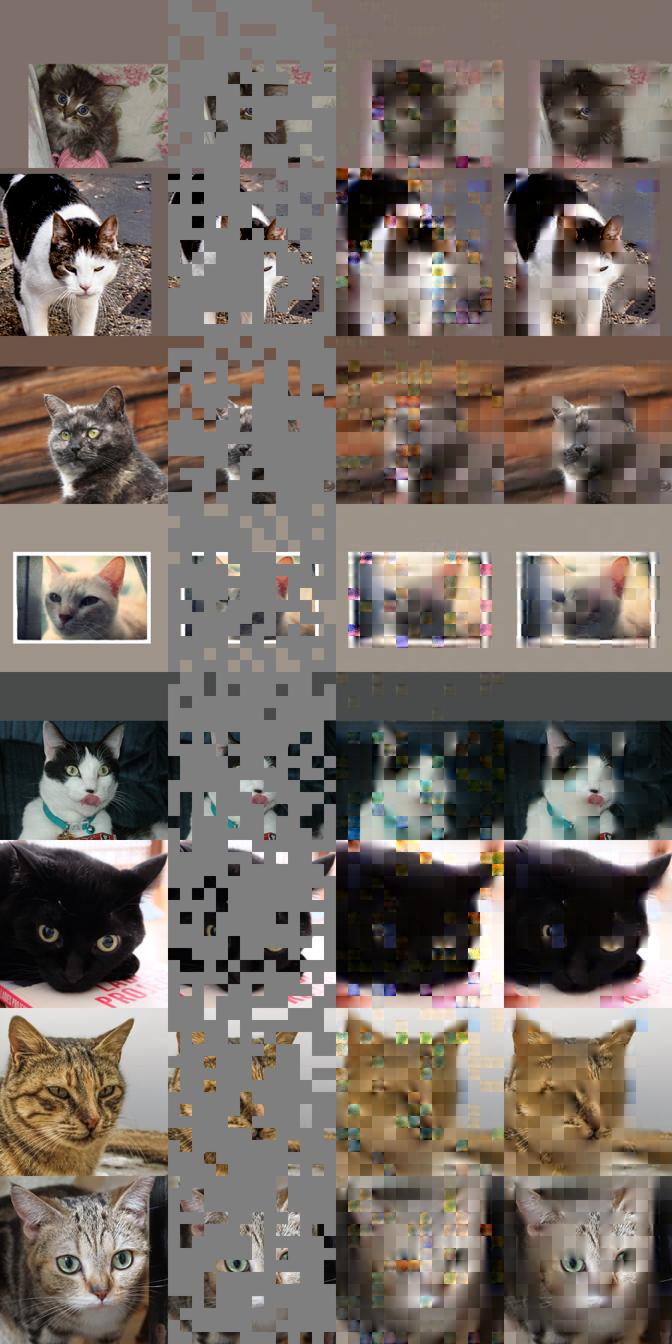

In [3]:
from IPython.display import Image as ShowImage

ShowImage(filename=str(RESULTS / "mae" / "reconstructions.png"), width=600)

My first reaction was that the reconstructions look disappointingly blurry. But blur is what this loss should
produce: when a hidden patch could contain many different fur patterns, the prediction that minimises the
squared error is their average, and an average of fur is a smear. The MAE paper's reconstructions look the same.

What matters is that the blur is in the *right place*. In the black cat's row the eye patch is hidden, and the
model still puts a yellow eye where the eye should be; in the tabby rows the stripes continue across hidden
patches. To do that, the encoder has to know where things are on a cat's face, and that knowledge is exactly what
I want to reuse for landmarks. (The third column looks like noise in the visible patches because the loss only
covers hidden patches, so the model is never asked to predict the visible ones.)

The decoder is thrown away after pretraining. Whether the encoder actually helps is a question for the next
section, where it gets the same fine-tuning as the baseline.

## The setup

Both runs use the same ViT-Small encoder (12 blocks, width 384, 16×16 patches on a 224×224 crop) with a small
ViTPose-style decoder that turns patch features into one heat map per landmark. I read each landmark off its heat
map with a soft-argmax (the expected position under the heat map) rather than the peak, so the model is trained
directly on the distance to the true point.

The training settings, straight from the run's config:

In [4]:
for name, run in runs.items():
    cfg = run["config"]["finetune"]
    minutes = sum(m["seconds"] for m in run["metrics"]) / 60
    print(f"{name} ({LABELS.get(name, name)})")
    print(f"  starting weights : {run['config']['init'] or 'random'}")
    print(f"  hardware         : {run['config'].get('hardware', 'unknown')}")
    faces = run["config"]["splits"]["train"]
    print(f"  epochs × batch   : {cfg['epochs']} × {cfg['batch']}  ({faces:,} training faces)")
    print(f"  learning rate    : {cfg['base_lr']} × batch/256, layer decay {cfg['layer_decay']}, "
          f"weight decay {cfg['weight_decay']}, drop path {cfg['drop_path']}")
    print(f"  augmentation     : zoom {cfg['zoom'][0]}-{cfg['zoom'][1]} face widths, "
          f"turn ±{cfg['turn_deg']}°, shift ±{cfg['shift']:.0%}, mirror, colour jitter")
    print(f"  training time    : {minutes:.0f} minutes")

pose_scratch (from scratch)
  starting weights : random
  hardware         : Kaggle, 1 x NVIDIA Tesla T4, float32
  epochs × batch   : 100 × 64  (7,996 training faces)
  learning rate    : 0.001 × batch/256, layer decay 0.75, weight decay 0.05, drop path 0.1
  augmentation     : zoom 1.0-2.0 face widths, turn ±25.0°, shift ±10%, mirror, colour jitter
  training time    : 187 minutes
pose_mae (from MAE)
  starting weights : runs/mae/encoder.pt
  hardware         : Kaggle, 1 x NVIDIA Tesla T4, float32
  epochs × batch   : 100 × 64  (7,996 training faces)
  learning rate    : 0.001 × batch/256, layer decay 0.75, weight decay 0.05, drop path 0.1
  augmentation     : zoom 1.0-2.0 face widths, turn ±25.0°, shift ±10%, mirror, colour jitter
  training time    : 210 minutes


## Learning curves

The first thing I check is whether training actually converged, and whether the validation error is still
falling when it stops.

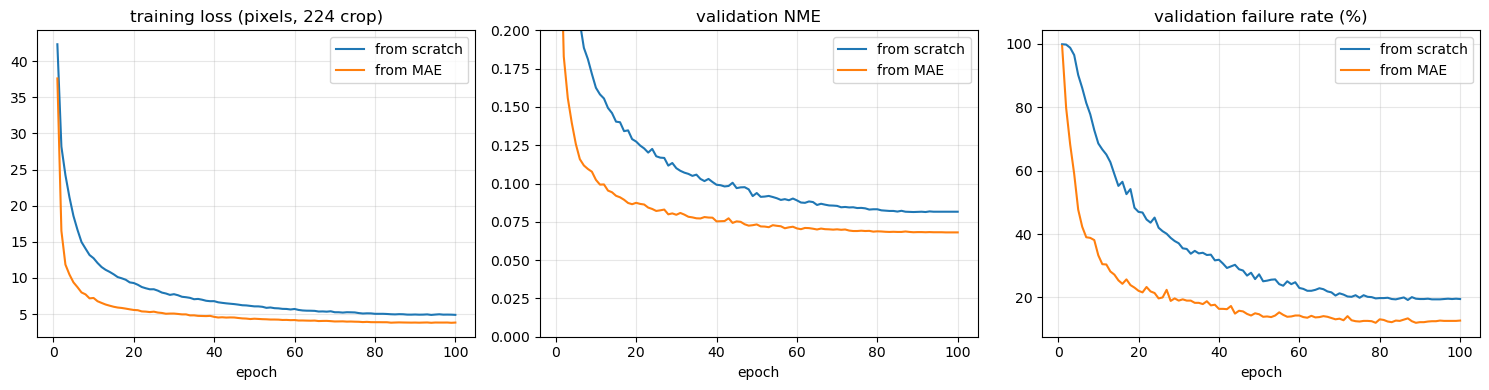

from scratch: best validation NME 0.0814 at epoch 89; epoch 40: 0.0992, epoch 80: 0.0832, last: 0.0816
from MAE: best validation NME 0.0681 at epoch 97; epoch 40: 0.0753, epoch 80: 0.0688, last: 0.0681


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, run in runs.items():
    m = run["metrics"]
    epochs = [r["epoch"] for r in m]
    label = LABELS.get(name, name)
    axes[0].plot(epochs, [r["train_px"] for r in m], label=label)
    axes[1].plot(epochs, [r["val_nme"] for r in m], label=label)
    axes[2].plot(epochs, [100 * r["val_failure_rate"] for r in m], label=label)
titles = ["training loss (pixels, 224 crop)", "validation NME", "validation failure rate (%)"]
for ax, title in zip(axes, titles, strict=True):
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()
axes[1].set_ylim(0, 0.2)
plt.tight_layout()
plt.show()

for name, run in runs.items():
    m = run["metrics"]
    best = min(m, key=lambda r: r["val_nme"])
    print(f"{LABELS.get(name, name)}: best validation NME {best['val_nme']:.4f} at epoch {best['epoch']}; "
          f"epoch 40: {m[39]['val_nme']:.4f}, epoch 80: {m[79]['val_nme']:.4f}, last: {m[-1]['val_nme']:.4f}")

What I see in the baseline: the error drops fast in the first 20 epochs and then slows down a lot. Between
epoch 80 and the end it barely moves, so training longer would not buy much. The training loss is still going
down while the validation error is flat, which tells me the model has learned about as much as it can generalise
from 8,000 labeled faces when it starts from nothing. That plateau is exactly what pretraining is supposed to lift.

And it does lift it. The MAE run starts far ahead (validation NME 0.102 after 10 epochs, where the baseline is at
0.163), passes the baseline's *best* error (0.0814) at epoch 28, and ends at 0.0681. Both runs flatten out over
the last 20 epochs, so the gap is not just the MAE run being further along the same curve: it settles lower.

## Which landmarks are hard?

Averaging over nine points hides a lot, so here is the error of each landmark separately.

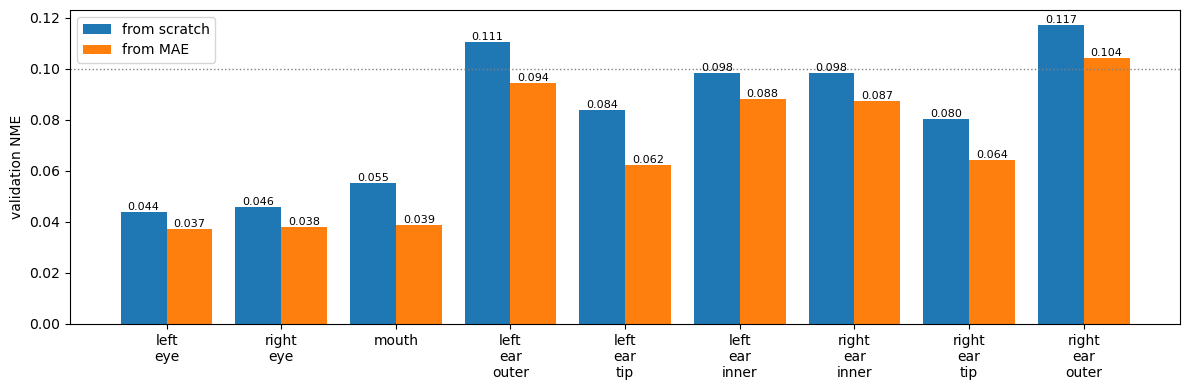

from scratch: NME 0.0814, failure rate 19.6% on 1,000 validation faces (best checkpoint)
from MAE: NME 0.0681, failure rate 12.6% on 1,000 validation faces (best checkpoint)


In [6]:
names = list(next(iter(runs.values()))["val"]["nme_per_landmark"])
x = np.arange(len(names))
width = 0.8 / len(runs)
fig, ax = plt.subplots(figsize=(12, 4))
for k, (name, run) in enumerate(runs.items()):
    values = [run["val"]["nme_per_landmark"][n] for n in names]
    bars = ax.bar(x + k * width, values, width, label=LABELS.get(name, name))
    ax.bar_label(bars, fmt="%.3f", fontsize=8)
ax.set_xticks(x + width * (len(runs) - 1) / 2, [n.replace("_", "\n") for n in names])
ax.set_ylabel("validation NME")
ax.axhline(0.1, color="grey", linestyle=":", linewidth=1)
ax.legend()
plt.tight_layout()
plt.show()

for name, run in runs.items():
    v = run["val"]
    print(f"{LABELS.get(name, name)}: NME {v['nme']:.4f}, failure rate {v['failure_rate_0.1']:.1%} "
          f"on {v['faces']:,} validation faces (best checkpoint)")

The eyes are the easiest points by far, then the mouth. The ears are clearly harder, and among the ear points the
**outer and inner bases** are the worst, while the ear tips are in between.

My explanation: an eye has a sharp, high-contrast outline, so there is one obvious place to put the point. An ear
tip is at least a corner. But the base of an ear just fades into the fur of the head; there is no edge that says
"here". I suspect the human annotators did not agree with each other on these points either, so part of this error
may be noise in the labels rather than a mistake by the model.

Before the MAE run I predicted that pretraining would help the ear bases most, because they are the points where
the model has to rely on its sense of the whole head. **That prediction was wrong.** On the validation split the
mouth improved the most (0.055 → 0.039) and the ear tips and eyes clearly improved, while the ear bases moved the
least (for example the right inner base 0.098 → 0.087). Pretraining made the model better at the points that were
already well defined; the ear bases stay the hardest points. That fits the label-noise explanation above: if the
annotators themselves disagree on where an ear base is, no amount of pretraining can make the model agree with
all of them.

## Looking at the predictions

Numbers are easy to misread, so I also look at the predictions. Below, the **dots are the hand-placed landmarks**
and the **crosses are the model's predictions**, on validation faces cut out the same way as during evaluation
(1.5 face widths around the face). The top rows are random faces; the bottom rows are the faces with the
**largest** error, because those are the ones that teach me something.

This cell needs the checkpoint (`runs/<run>/best.pt`) and the crop cache (`data/cache/cat`), which are too big for
git; without them it only prints a note, and the saved figure below stays as it was.

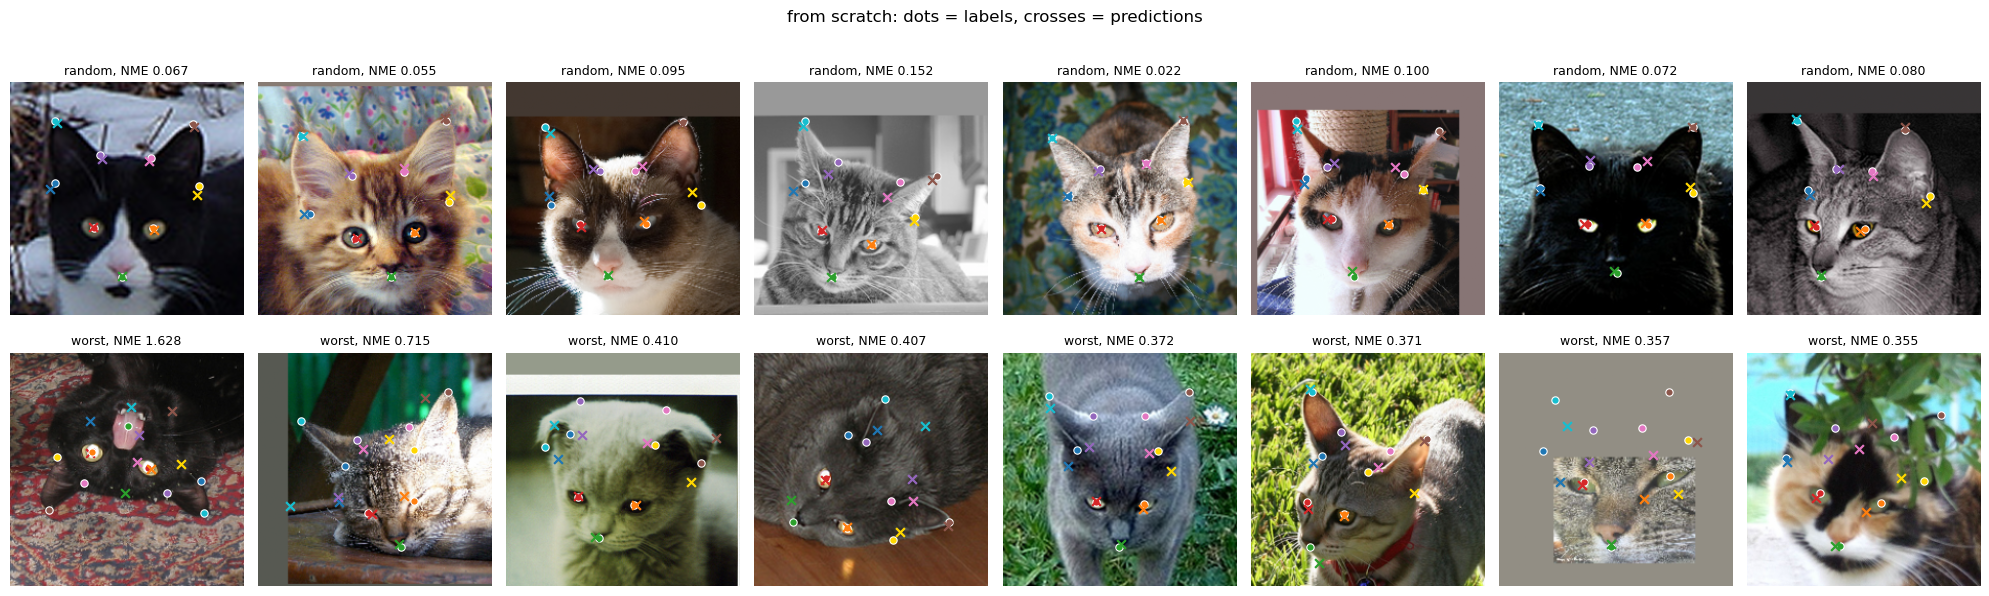

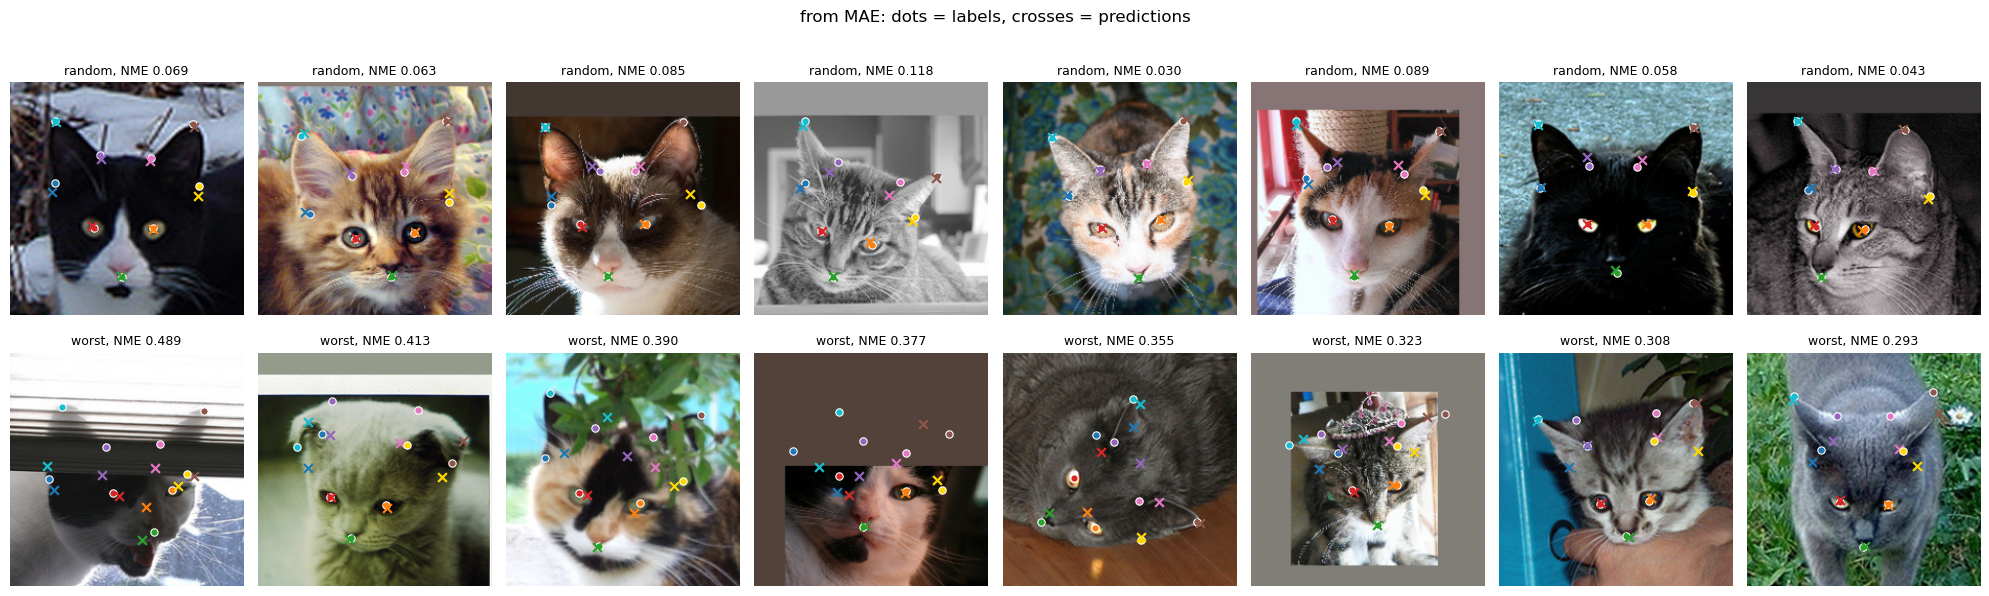

In [7]:
import sys

import torch

sys.path.insert(0, str(ROOT))
from catlandmarks import augment
from catlandmarks.finetune import Faces, FinetuneConfig, crops, load
from catlandmarks.pose import normalised_error
from catlandmarks.pretrain import MEAN, STD

COLOURS = ["tab:red", "tab:orange", "tab:green", "tab:blue", "tab:cyan", "tab:purple", "tab:pink", "tab:brown", "gold"]


def show_predictions(run_name: str, n_random: int = 8, n_worst: int = 8, seed: int = 0):
    checkpoint, cache = ROOT / "runs" / run_name, ROOT / "data" / "cache" / "cat"
    if not (checkpoint / "best.pt").exists() or not (cache / "images.npy").exists():
        print(f"{run_name}: checkpoint or crop cache not found, skipping")
        return
    dev = torch.device("cpu")
    cfg, faces, model = FinetuneConfig(cache=str(cache)), Faces(cache), load(checkpoint, dev)
    which = faces.splits["val"]
    errors = []
    with torch.no_grad():
        for i in range(0, len(which), 100):
            chunk = which[i:i + 100]
            images, true = crops(faces, chunk, augment.centre_crop(len(chunk), faces.face, cfg.eval_zoom), 224, dev)
            errors.append(normalised_error(model(images)[0], true).mean(1))
    errors = torch.cat(errors).numpy()
    rng = np.random.default_rng(seed)
    picks = list(rng.choice(len(which), n_random, replace=False)) + list(np.argsort(-errors)[:n_worst])
    chunk = which[picks]
    images, true = crops(faces, chunk, augment.centre_crop(len(chunk), faces.face, cfg.eval_zoom), 224, dev)
    with torch.no_grad():
        pred = model(images)[0]
    pixels = (images * STD + MEAN).clamp(0, 1).permute(0, 2, 3, 1).numpy()
    fig, axes = plt.subplots((len(picks) + 7) // 8, 8, figsize=(20, 6.2))
    for k, ax in enumerate(axes.ravel()):
        ax.imshow(pixels[k])
        for j, colour in enumerate(COLOURS):
            ax.scatter(*true[k, j].numpy(), s=28, c=colour, edgecolors="white", linewidths=0.8)
            ax.scatter(*pred[k, j].numpy(), s=40, c=colour, marker="x", linewidths=1.6)
        tag = "random" if k < n_random else "worst"
        ax.set_title(f"{tag}, NME {errors[picks[k]]:.3f}", fontsize=9)
        ax.axis("off")
    plt.suptitle(f"{LABELS.get(run_name, run_name)}: dots = labels, crosses = predictions", y=1.0)
    plt.tight_layout()
    plt.show()


for name in runs:
    show_predictions(name)

On the random faces the crosses mostly sit on top of the dots, especially around the eyes and mouth. Even
the two black cats in the top row are fine, which surprised me: I expected dark fur to be a problem.

The worst faces are where it gets interesting, and they fall into a few groups:

- **Heads turned far past the rotations I trained with.** The single worst face (NME 1.63) is a cat lying upside
  down on a rug, and the model still lays its nine points out as an upright face. Two more (0.72 and 0.41) are cats
  lying down with their heads tilted roughly 70–90°. I only augmented with turns of ±25°, so this looks like a gap
  in my augmentation rather than just hard images.
- **Unusual viewpoints.** One cat is walking towards the camera with its head lowered, seen from above, and one
  has its head turned to the side. The ears look very different from these angles.
- **An unusual ear shape.** A Scottish Fold, whose ears fold forward and down, so its ear bases and tips are not
  where they are on almost every other cat in the training set.
- **Labels outside the photo.** In one crop the cat's face sits at the edge of the original photo, so the
  hand-placed ear points are out in the grey fill where there is nothing to see. No model can get those right.
- **Occlusion.** A calico behind leaves, where the leaves cover one eye and an ear.

So part of the 19.6% failure rate is the model, and part is faces that are rotated more than anything it has
seen or whose labels cannot be checked from the pixels. I'm keeping all of them in the evaluation anyway, because
dropping hard cases would make the number look better without making the model any better.

**With MAE pretraining**, the random faces look much the same (the points were already mostly right), but the list
of worst faces changes. The upside-down cat that the baseline got completely wrong (1.63) drops to 0.19, and the
cat with its head turned about 70–90° drops from 0.72 to 0.21. Neither is a success yet, but the model no longer
lays out an upright face on a rotated one. The Scottish Fold (0.41 → 0.41), the calico behind the leaves and the
faces whose labels lie outside the photo stay bad in both runs, which is what I would expect: pretraining
cannot fix an ear shape it has hardly seen or labels that cannot be checked from the pixels. The MAE run's worst
face is new: a cat peering under window blinds, where it gets 0.49 and the baseline got 0.21; the blinds' stripes
seem to pull its ear points down into the slats.

Counting over all 1,000 validation faces: the MAE model has the lower error on 74% of them. 114 faces fail
(NME above 0.1) in both runs, 82 fail only from scratch, and 12 fail only with MAE.

(While making this figure I found a bug: my batch loader read faces in sorted order for speed and returned them
that way, so the first version of this plot showed each face with another face's error. Training and evaluation
were not affected, since images and labels were always sorted together, but the loader now returns faces in the
order they were asked for, and there is a test for it.)

## The test set

Everything above was measured on the validation split, which also picked the best epoch of each run, so those
numbers are slightly optimistic. The test split (1,000 faces neither run has ever been scored on) was evaluated
exactly once for each run, after both were finished. These are the numbers I would quote.

In [8]:
rows = [("NME", "nme", "{:.4f}"), ("failure rate (NME > 0.1)", "failure_rate_0.1", "{:.1%}")]
header = f"{'':28}" + "".join(f"{LABELS.get(n, n):>16}" for n in runs)
print(header)
for title, key, fmt in rows:
    print(f"{title:28}" + "".join(f"{fmt.format(run['test'][key]):>16}" for run in runs.values()))
print()
for landmark in names:
    print(f"  {landmark:26}" + "".join(f"{run['test']['nme_per_landmark'][landmark]:>16.4f}" for run in runs.values()))

if {"pose_scratch", "pose_mae"} <= set(runs):
    before, after = runs["pose_scratch"]["test"], runs["pose_mae"]["test"]
    print(f"\nMAE pretraining lowers the test NME by {1 - after['nme'] / before['nme']:.0%} "
          f"and the failure rate from {before['failure_rate_0.1']:.1%} to {after['failure_rate_0.1']:.1%}.")

                                from scratch        from MAE
NME                                   0.0780          0.0670
failure rate (NME > 0.1)               21.4%           12.2%

  left_eye                            0.0460          0.0376
  right_eye                           0.0459          0.0379
  mouth                               0.0520          0.0388
  left_ear_outer                      0.1061          0.0928
  left_ear_tip                        0.0724          0.0567
  left_ear_inner                      0.0950          0.0859
  right_ear_inner                     0.0951          0.0891
  right_ear_tip                       0.0690          0.0561
  right_ear_outer                     0.1202          0.1082

MAE pretraining lowers the test NME by 14% and the failure rate from 21.4% to 12.2%.


## What I take away

The test numbers agree with validation: pretraining the encoder as a masked autoencoder on unlabeled cats lowers
the test NME from 0.078 to 0.067 (14%) and cuts the failure rate from 21.4% to 12.2%, with every other setting,
the GPU type and the number of epochs held fixed. The cost was the 8 hours of pretraining on my laptop; the
fine-tuning itself took about as long as the baseline (210 against 187 minutes on the same Kaggle T4).

Two things I did not expect: the gain was largest on the mouth and the ear tips, not the ear bases, and the
biggest single improvements were on rotated faces, even though the augmentation was identical. My guess is that
the pretraining crops showed the encoder far more cat heads (13,061 faces against 7,996), but I have not tested that.

What I would try next:

1. **Larger rotations in fine-tuning.** The remaining failures are still dominated by heads turned past ±25°.
2. **Labeling AFHQ with the MAE model.** That is what this model was built for: AFHQ's sharp, aligned faces have no
   landmarks, and the MAE encoder has already seen them during pretraining.
3. **A small hand-labeled AFHQ test set**, to measure how well the model transfers rather than assuming it does.